In [15]:
import os
import pandas as pd
import numpy as np
import re 
import matplotlib.pyplot as plt
import seaborn as sns
import calendar




# --- Configuration ---
path_to_scenarios = '/home/abhis/india_power/scenarios'
path_to_save_images = '/home/abhis/india_power/images'
# scenario_names = ['iced_2050_cc_1','iced_2050_cc_2','iced_2050_cc_3'] # Example: Explicit list
# scenario_names = ['pier_mid_ra_2040_1','pier_mid_ra_2040_2','pier_mid_ra_2040_3'] # Example: Explicit list

scenario_names = ['capex_pier_prm_108_cc_90_hardovergen_2040_1','capex_pier_prm_108_cc_90_hardovergen_2040_2','capex_pier_prm_108_cc_90_hardovergen_2040_3']
                # 'capex_pier_prm_108_cc_90_hardovergen_2040_4','capex_pier_prm_108_cc_90_hardovergen_2040_5','capex_pier_prm_108_cc_90_hardovergen_2040_6',
                # 'capex_pier_prm_108_cc_90_hardovergen_2040_7','capex_pier_prm_108_cc_90_hardovergen_2040_8','capex_pier_prm_108_cc_90_hardovergen_2040_9',
                # 'capex_pier_prm_108_cc_90_hardovergen_2040_10','capex_pier_prm_108_cc_90_hardovergen_2040_11','capex_pier_prm_108_cc_90_hardovergen_2040_12',
                # 'capex_pier_prm_108_cc_90_hardovergen_2040_13','capex_pier_prm_108_cc_90_hardovergen_2040_14','capex_pier_prm_108_cc_90_hardovergen_2040_15',
                # 'capex_pier_prm_108_cc_90_hardovergen_2040_16','capex_pier_prm_108_cc_90_hardovergen_2040_17','capex_pier_prm_108_cc_90_hardovergen_2040_18'] # Example: Explicit list


In [7]:
project_timepoint_dtypes = {
    'timepoint':            'int64',
    'load_zone':            'category',
    'technology':           'category',
    'power_mw':             'float32',
    'starting_energy_mwh':  'float32',
    'charge_mw':            'float32',
    'discharge_mw':         'float32',
    'net_power_mw':         'float32',
    'total_curtailment_mw': 'float32',
}
columns_to_read = list(project_timepoint_dtypes.keys())
print(f"Reading project_timepoint columns: {columns_to_read}")

chunk_size = 100_000
all_project_timepoint_data = []
all_system_load_data      = []

# --- Traverse scenario folders ---
for scenario_name in scenario_names:
    scenario_path = os.path.join(path_to_scenarios, scenario_name)
    if not os.path.isdir(scenario_path):
        print(f"Warning: Scenario directory not found: {scenario_path}")
        continue

    for weather_folder in os.listdir(scenario_path):
        if not weather_folder.startswith('weather_iteration_'):
            continue
        weather_iteration = int(re.search(r'\d+', weather_folder).group())
        weather_path      = os.path.join(scenario_path, weather_folder)

        for hydro_folder in os.listdir(weather_path):
            if not hydro_folder.startswith('hydro_iteration_'):
                continue
            hydro_iteration = int(re.search(r'\d+', hydro_folder).group())
            hydro_path      = os.path.join(weather_path, hydro_folder)

            for avail_folder in os.listdir(hydro_path):
                if not avail_folder.startswith('availability_iteration_'):
                    continue
                availability_iteration = int(re.search(r'\d+', avail_folder).group())
                avail_path             = os.path.join(hydro_path, avail_folder)
                results_path           = os.path.join(avail_path, 'results')

                # --- project_timepoint.csv ---
                proj_path = os.path.join(results_path, 'project_timepoint.csv')
                if os.path.exists(proj_path):
                    try:
                        reader = pd.read_csv(
                            proj_path,
                            dtype=project_timepoint_dtypes,
                            usecols=columns_to_read,
                            chunksize=chunk_size
                        )
                        for chunk in reader:
                            # add iteration metadata
                            chunk['weather_iteration']      = weather_iteration
                            chunk['hydro_iteration']        = hydro_iteration
                            chunk['availability_iteration'] = availability_iteration

                            # Keep all technologies; collapse later if needed
                            # Downcast iteration columns
                            chunk = chunk.astype({
                                'weather_iteration':      'int16',
                                'hydro_iteration':        'int16',
                                'availability_iteration': 'int16'
                            })

                            # Reorder columns
                            it_cols = ['weather_iteration','hydro_iteration','availability_iteration']
                            orig    = [c for c in columns_to_read if c in chunk]
                            chunk   = chunk[it_cols + orig]

                            all_project_timepoint_data.append(chunk)
                    except Exception as e:
                        print(f"Error processing {proj_path}: {e}")
                else:
                    print(f"Warning: project_timepoint.csv not found in {results_path}")

                # --- system_load_zone_timepoint.csv ---
                sys_path = os.path.join(results_path, 'system_load_zone_timepoint.csv')
                if os.path.exists(sys_path):
                    try:
                        df_sys = pd.read_csv(sys_path)
                        df_sys['scenario_name']          = scenario_name
                        df_sys['weather_iteration']      = weather_iteration
                        df_sys['hydro_iteration']        = hydro_iteration
                        df_sys['availability_iteration'] = availability_iteration

                        it_cols = ['scenario_name','weather_iteration','hydro_iteration','availability_iteration']
                        others  = [c for c in df_sys.columns if c not in it_cols]
                        df_sys  = df_sys[it_cols + others]

                        all_system_load_data.append(df_sys)
                    except Exception as e:
                        print(f"Error reading {sys_path}: {e}")
                else:
                    print(f"Warning: system_load_zone_timepoint.csv not found in {results_path}")

# --- Concatenate project_timepoint data ---
if all_project_timepoint_data:
    final_project_timepoint_df = pd.concat(all_project_timepoint_data, ignore_index=True)
    print("Combined project_timepoint DataFrame created.")
else:
    print("No project_timepoint data found.")

# --- Concatenate system_load data ---
if all_system_load_data:
    final_system_load_df = pd.concat(all_system_load_data, ignore_index=True)
    print("Combined system_load_zone_timepoint DataFrame created.")
else:
    print("No system_load_zone_timepoint data found.")

# --- Add timestamp to project_timepoint ---
if 'final_project_timepoint_df' in locals() and not final_project_timepoint_df.empty:
    dfp = final_project_timepoint_df
    dfp['timepoint_str'] = dfp['timepoint'].astype(str)
    dfp['date_str']      = dfp['timepoint_str'].str[:8]
    dfp['hour_str']      = dfp['timepoint_str'].str[8:]
    dfp['hour_int']      = dfp['hour_str'].astype(int) - 1

    dfp['timestamp'] = (
        pd.to_datetime(dfp['date_str'], format='%Y%m%d')
        + pd.to_timedelta(dfp['hour_int'], unit='h')
    )
    dfp.drop(columns=['timepoint_str','date_str','hour_str','hour_int'], inplace=True)

    cols = list(dfp.columns)
    cols.insert(0, cols.pop(cols.index('timestamp')))
    final_project_timepoint_df = dfp[cols]
    print("Timestamp added to project_timepoint DataFrame.")

# --- Add timestamp to system_load DataFrame ---
if 'final_system_load_df' in locals() and not final_system_load_df.empty:
    dfs = final_system_load_df
    dfs['timepoint_str'] = dfs['timepoint'].astype(str)
    dfs['date_str']      = dfs['timepoint_str'].str[:8]
    dfs['hour_str']      = dfs['timepoint_str'].str[8:]
    dfs['hour_int']      = dfs['hour_str'].astype(int) - 1

    dfs['timestamp'] = (
        pd.to_datetime(dfs['date_str'], format='%Y%m%d')
        + pd.to_timedelta(dfs['hour_int'], unit='h')
    )
    dfs.drop(columns=['timepoint_str','date_str','hour_str','hour_int'], inplace=True)

    cols = list(dfs.columns)
    cols.insert(0, cols.pop(cols.index('timestamp')))
    final_system_load_df = dfs[cols]
    print("Timestamp added to system_load DataFrame.")

# drop scenario_name if present
if 'final_system_load_df' in locals() and 'scenario_name' in final_system_load_df.columns:
    final_system_load_df.drop(columns=['scenario_name'], inplace=True)
    print("Dropped 'scenario_name' from system load DataFrame.")




Reading project_timepoint columns: ['timepoint', 'load_zone', 'technology', 'power_mw', 'starting_energy_mwh', 'charge_mw', 'discharge_mw', 'net_power_mw', 'total_curtailment_mw']
Combined project_timepoint DataFrame created.
Combined system_load_zone_timepoint DataFrame created.
Timestamp added to project_timepoint DataFrame.
Timestamp added to system_load DataFrame.
Dropped 'scenario_name' from system load DataFrame.


/tmp/ipykernel_1543457/2484339521.py:154: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  final_system_load_df.drop(columns=['scenario_name'], inplace=True)


In [8]:
merged_df = pd.merge(final_project_timepoint_df, final_system_load_df, on=['timestamp','weather_iteration','hydro_iteration',
                                                                           'availability_iteration','timepoint','load_zone'], how='inner')

# comment if state wise plots needed

In [9]:
national_df = (
    merged_df
    .groupby(
        ['timestamp',
         'weather_iteration',
         'hydro_iteration',
         'availability_iteration',
         'timepoint',
         'technology'],
        as_index=False
    )
    .agg({
        'power_mw':             'sum',
        'static_load_mw':       'sum',
        'total_curtailment_mw': 'sum'
    })
)
national_df['load_zone'] = 'India'


# define a mapping from the detailed tech names to your two broad categories
tech_map = {
    'SolarPV_tilt':   'Solar',
    'SolarPV_single': 'Solar',
    'SolarPV_roof':   'Solar',
    'Wind':           'Wind',
    'Offshore':       'Wind'
}

# apply it in-place (leaving any other tech names untouched)
national_df['technology'] = (
    national_df['technology']
    .replace(tech_map)
)


# uncomment if state wise plots needed.

In [10]:
# load_zone='Maharashtra'
# national_df = (
#     merged_df
#     .groupby(
#         ['timestamp',
#          'weather_iteration',
#          'hydro_iteration',
#          'availability_iteration',
#          'timepoint',
#          'technology',
#          'load_zone'],
#         as_index=False
#     )
#     .agg({
#         'power_mw':             'sum',
#         'static_load_mw':       'sum',
#         'total_curtailment_mw': 'sum'
#     })
# )

# # define a mapping from the detailed tech names to your two broad categories
# tech_map = {
#     'SolarPV_tilt':   'Solar',
#     'SolarPV_single': 'Solar',
#     'SolarPV_roof':   'Solar',
#     'Wind':           'Wind',
#     'Offshore':       'Wind'
# }

# # apply it in-place (leaving any other tech names untouched)
# national_df['technology'] = (
#     national_df['technology']
#     .replace(tech_map)
# )

In [11]:
# Calculate national demand from final_system_load_df
# This DataFrame has static_load_mw per load_zone for each timestamp and iteration set.
# Grouping by timestamp and iterations and summing static_load_mw will give total national demand.
demand_df = final_system_load_df.groupby(
    ['timestamp', 'weather_iteration', 'hydro_iteration', 'availability_iteration'],
    as_index=False
)['static_load_mw'].sum().rename(columns={'static_load_mw': 'demand'})

# Calculate VRE generation from national_df
# national_df already has power_mw aggregated nationally per technology.
# We filter for 'Solar' and 'Wind' and then sum their power_mw.
vre_technologies = ['Solar', 'Wind']
vre_generation_df = national_df[national_df['technology'].isin(vre_technologies)]

vre_gen_df = vre_generation_df.groupby(
    ['timestamp', 'weather_iteration', 'hydro_iteration', 'availability_iteration'],
    as_index=False
)['power_mw'].sum().rename(columns={'power_mw': 'vre_gen'})

# Merge demand and VRE generation
summary_df = pd.merge(
    demand_df,
    vre_gen_df,
    on=['timestamp', 'weather_iteration', 'hydro_iteration', 'availability_iteration'],
    how='left'  # Use left merge to ensure all demand timestamps are kept
)

# Fill NaN values in 'vre_gen' with 0 (in case some timestamps have demand but no VRE generation)
summary_df['vre_gen'] = summary_df['vre_gen'].fillna(0)


print("Summary DataFrame with demand and VRE generation:")
print(summary_df.head())
print(f"\nShape of the summary DataFrame: {summary_df.shape}")

Summary DataFrame with demand and VRE generation:
            timestamp  weather_iteration  hydro_iteration  \
0 2040-04-01 00:00:00                  1                1   
1 2040-04-01 00:00:00                  2                2   
2 2040-04-01 00:00:00                  3                3   
3 2040-04-01 01:00:00                  1                1   
4 2040-04-01 01:00:00                  2                2   

   availability_iteration         demand        vre_gen  
0                       1  356639.894731  243712.562500  
1                       2  344471.731626  134750.500000  
2                       3  333142.308974  179913.203125  
3                       1  354083.814421  234833.359375  
4                       2  340503.702730  133639.750000  

Shape of the summary DataFrame: (26280, 6)


In [12]:
# Copy the summary to a new DataFrame (optional)
netdemand_df = summary_df.copy()

# Calculate net demand
netdemand_df['net_demand'] = netdemand_df['demand'] - netdemand_df['vre_gen']

# Inspect
print("Net‐Demand DataFrame:")
print(netdemand_df.head())
print(f"\nShape: {netdemand_df.shape}")


Net‐Demand DataFrame:
            timestamp  weather_iteration  hydro_iteration  \
0 2040-04-01 00:00:00                  1                1   
1 2040-04-01 00:00:00                  2                2   
2 2040-04-01 00:00:00                  3                3   
3 2040-04-01 01:00:00                  1                1   
4 2040-04-01 01:00:00                  2                2   

   availability_iteration         demand        vre_gen     net_demand  
0                       1  356639.894731  243712.562500  112927.332231  
1                       2  344471.731626  134750.500000  209721.231626  
2                       3  333142.308974  179913.203125  153229.105849  
3                       1  354083.814421  234833.359375  119250.455046  
4                       2  340503.702730  133639.750000  206863.952730  

Shape: (26280, 7)


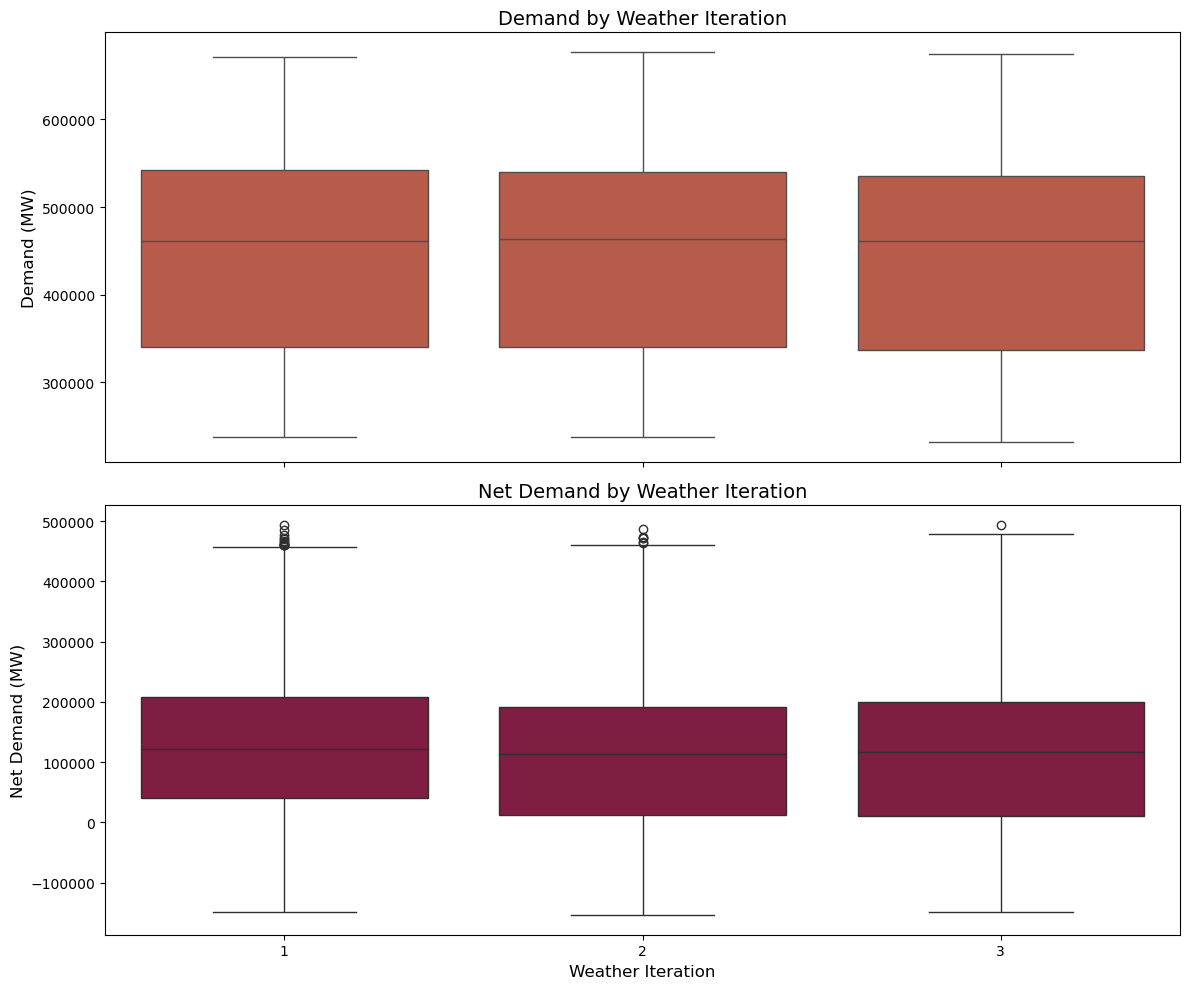

Figure saved to /home/abhis/india_power/images/demand_netdemand_weather_iteration.png


<Figure size 640x480 with 0 Axes>

In [16]:
fig, axes = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

# Plot 1: Demand vs Weather Iteration
sns.boxplot(x='weather_iteration', y='demand', data=netdemand_df, ax=axes[0], color='#C94F39')
axes[0].set_title('Demand by Weather Iteration', fontsize=14)
axes[0].set_ylabel('Demand (MW)', fontsize=12)
axes[0].set_xlabel('') # Hide x-label for the top plot

# Plot 2: Net Demand vs Weather Iteration
sns.boxplot(x='weather_iteration', y='net_demand', data=netdemand_df, ax=axes[1], color='#900C3F')
axes[1].set_title('Net Demand by Weather Iteration', fontsize=14)
axes[1].set_ylabel('Net Demand (MW)', fontsize=12)
axes[1].set_xlabel('Weather Iteration', fontsize=12)

plt.tight_layout()
plt.show()
# Save the figure
output_path = os.path.join(path_to_save_images, 'demand_netdemand_weather_iteration.png')
plt.savefig(output_path, dpi=300)
print(f"Figure saved to {output_path}")

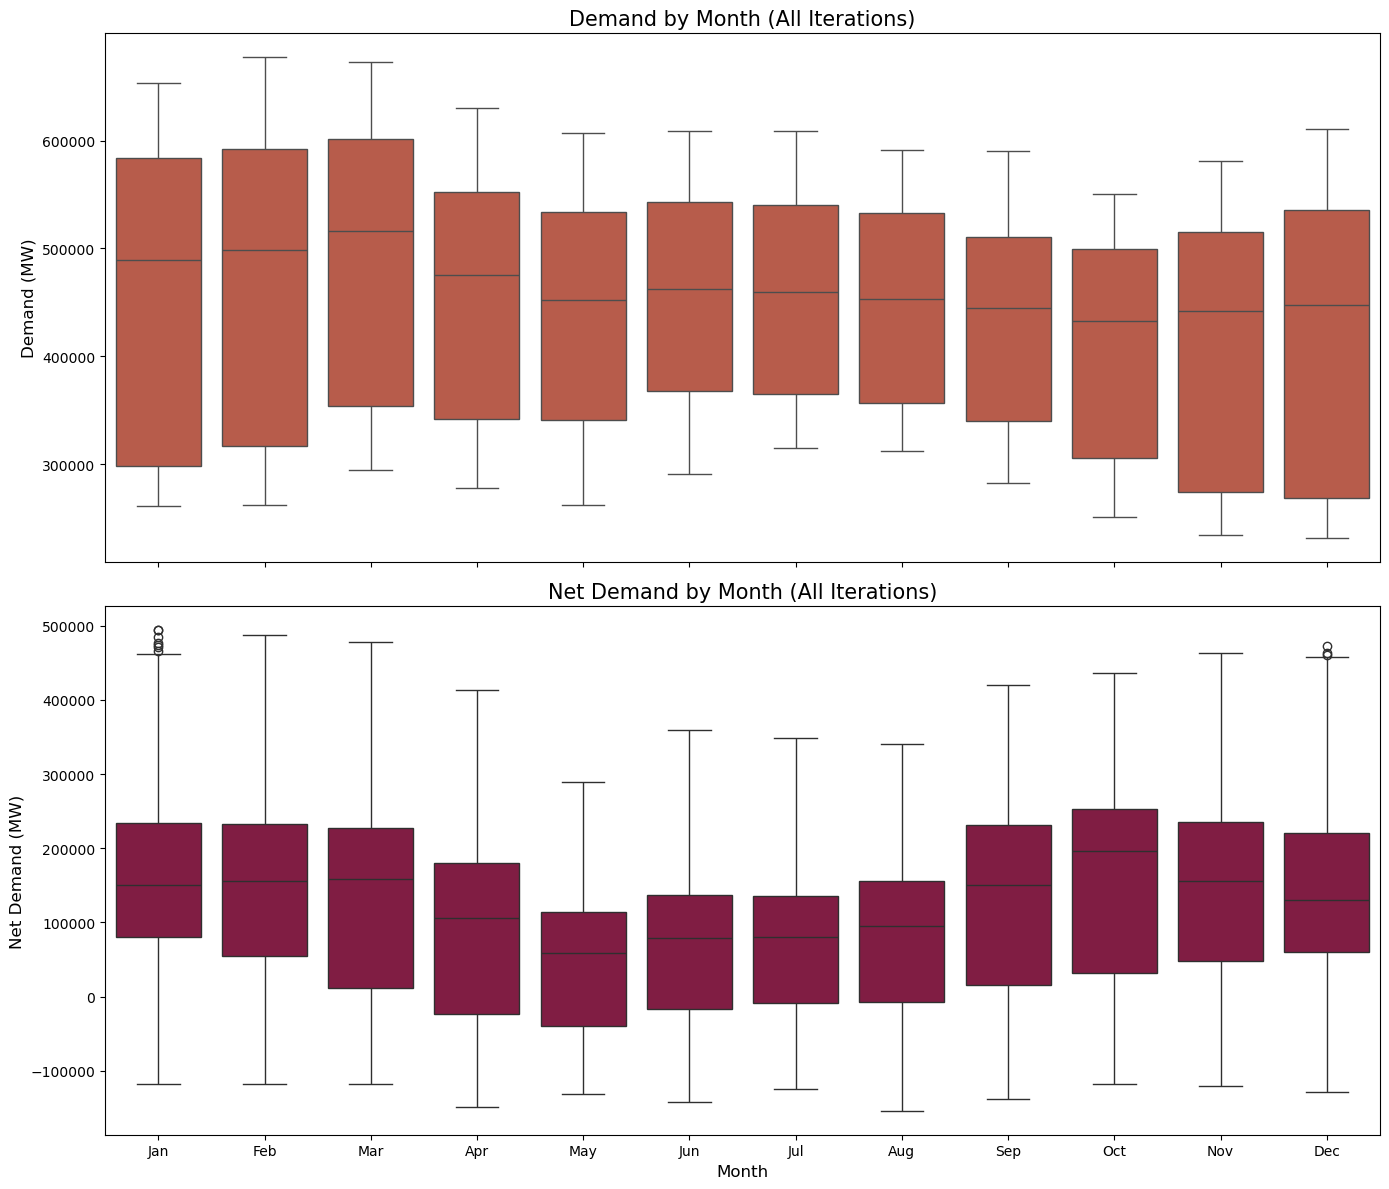

Figure saved to /home/abhis/india_power/images/demand_netdemand_month.png


<Figure size 640x480 with 0 Axes>

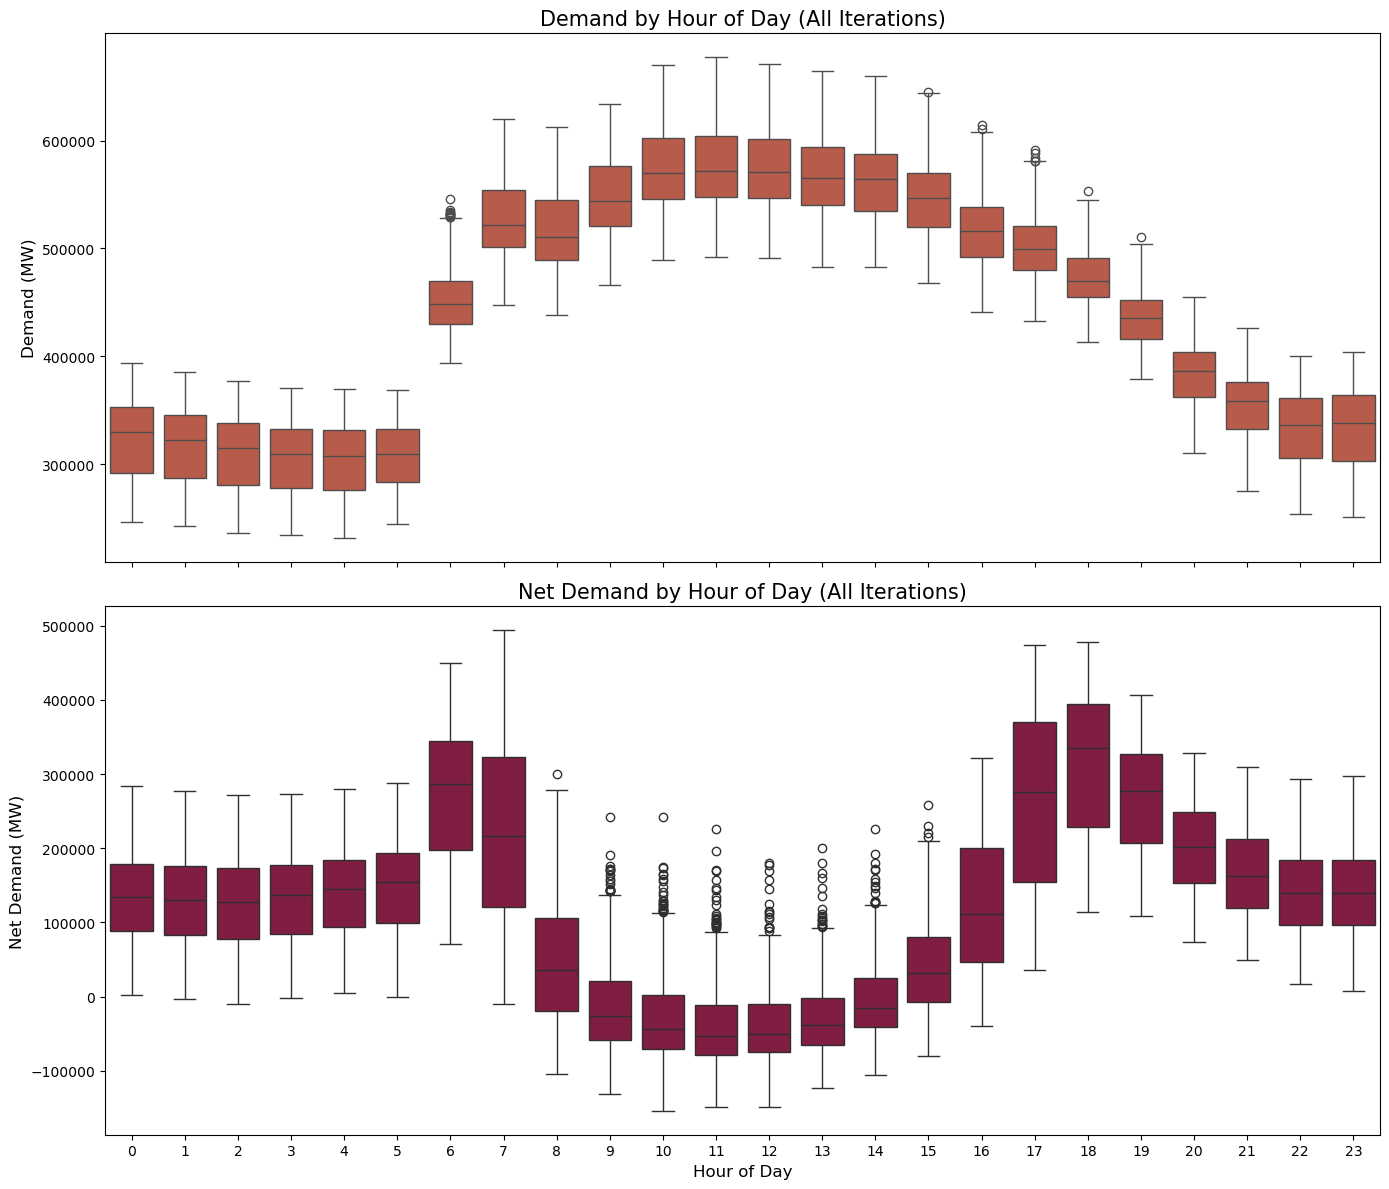

Figure saved to /home/abhis/india_power/images/demand_netdemand_month_hour.png


<Figure size 640x480 with 0 Axes>

In [17]:
# Create a working copy of netdemand_df
plot_df = netdemand_df.copy()

# Ensure 'timestamp' is datetime
plot_df['timestamp'] = pd.to_datetime(plot_df['timestamp'])

# Extract month and hour
plot_df['month_num'] = plot_df['timestamp'].dt.month
plot_df['month'] = plot_df['month_num'].apply(lambda x: calendar.month_abbr[x])
plot_df['hour'] = plot_df['timestamp'].dt.hour

# Define month order for plotting
month_order = list(calendar.month_abbr)[1:] # ['Jan', 'Feb', ..., 'Dec']

# --- Plot 1: Demand and Net Demand by Month ---
fig, axes = plt.subplots(2, 1, figsize=(14, 12), sharex=True)

# Demand by Month
sns.boxplot(x='month', y='demand', data=plot_df, order=month_order, ax=axes[0], color='#C94F39')
axes[0].set_title('Demand by Month (All Iterations)', fontsize=15)
axes[0].set_ylabel('Demand (MW)', fontsize=12)
axes[0].set_xlabel('')

# Net Demand by Month
sns.boxplot(x='month', y='net_demand', data=plot_df, order=month_order, ax=axes[1], color='#900C3F')
axes[1].set_title('Net Demand by Month (All Iterations)', fontsize=15)
axes[1].set_ylabel('Net Demand (MW)', fontsize=12)
axes[1].set_xlabel('Month', fontsize=12)

plt.tight_layout()
plt.show()
# Save the figure
output_path = os.path.join(path_to_save_images, 'demand_netdemand_month.png')
plt.savefig(output_path, dpi=300)
print(f"Figure saved to {output_path}")

# --- Plot 2: Demand and Net Demand by Hour of Day ---
fig, axes = plt.subplots(2, 1, figsize=(14, 12), sharex=True)

# Demand by Hour
sns.boxplot(x='hour', y='demand', data=plot_df, ax=axes[0], color='#C94F39')
axes[0].set_title('Demand by Hour of Day (All Iterations)', fontsize=15)
axes[0].set_ylabel('Demand (MW)', fontsize=12)
axes[0].set_xlabel('')

# Net Demand by Hour
sns.boxplot(x='hour', y='net_demand', data=plot_df, ax=axes[1], color='#900C3F')
axes[1].set_title('Net Demand by Hour of Day (All Iterations)', fontsize=15)
axes[1].set_ylabel('Net Demand (MW)', fontsize=12)
axes[1].set_xlabel('Hour of Day', fontsize=12)

plt.tight_layout()
plt.show()
# Save the figure
output_path = os.path.join(path_to_save_images, 'demand_netdemand_month_hour.png')
plt.savefig(output_path, dpi=300)
print(f"Figure saved to {output_path}")

In [ ]:
solar_df=national_df.copy()
solar_df=solar_df[solar_df['technology']=='Solar']

solar_national_df=solar_df.groupby(['timestamp','weather_iteration','hydro_iteration','availability_iteration']).sum('power_mw').reset_index()
solar_national_df['load_zone']='National'

wind_df = national_df.copy()
wind_df = wind_df[wind_df['technology'] == 'Wind']

wind_national_df = wind_df.groupby(['timestamp','weather_iteration','hydro_iteration','availability_iteration']).sum('power_mw').reset_index()
wind_national_df['load_zone'] = 'National'


In [ ]:

sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(2, 1, figsize=(10, 12), sharex=True)

# Top: Solar
sns.boxplot(
    x='weather_iteration',
    y='power_mw',
    data=solar_national_df,
    color='#EF9226',
    ax=axes[0]
)
axes[0].set_title('Solar Power Generation by Weather Iteration', fontsize=14, fontweight='normal')
axes[0].set_xlabel('')  # hide x‐label on top plot
axes[0].set_ylabel('Generation (MW)', fontsize=12)

# Bottom: Wind
sns.boxplot(
    x='weather_iteration',
    y='power_mw',
    data=wind_national_df,
    color='#8DC0CD',
    ax=axes[1]
)
axes[1].set_title('Wind Power Generation by Weather Iteration', fontsize=14, fontweight='normal')
axes[1].set_xlabel('Weather Iteration', fontsize=12)
axes[1].set_ylabel('Generation (MW)', fontsize=12)

plt.tight_layout()
plt.show()
# Save the figure
output_path = os.path.join(path_to_save_images, 'solar_wind_weather_iteration.png')
plt.savefig(output_path, dpi=300)
print(f"Figure saved to {output_path}")


In [ ]:
# Calculate average daily demand for plotting
# Group by weather_iteration, hydro_iteration, and the date part of timestamp.
# Then calculate the mean of 'static_load_mw' for each day.
avg_daily_solar_per_day = solar_national_df.groupby(
    ['weather_iteration', 'hydro_iteration', solar_national_df['timestamp'].dt.date]
)['power_mw'].mean().reset_index()

total_daily_solar_per_day = solar_national_df.groupby(
    ['weather_iteration', 'hydro_iteration', solar_national_df['timestamp'].dt.date]
)['power_mw'].sum().reset_index()


# The column derived from solar_national_df['timestamp'].dt.date will be named 'timestamp' by default.
# It's good practice to rename it to 'date' for clarity, though not strictly needed for this plot.
avg_daily_solar_per_day = avg_daily_solar_per_day.rename(columns={'timestamp': 'date'})
total_daily_solar_per_day = total_daily_solar_per_day.rename(columns={'timestamp': 'date'})

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: Average Daily Solar
sns.boxplot(
    x='weather_iteration',
    y='power_mw',
    data=avg_daily_solar_per_day,
    color='#EF9226',
    ax=axes[0]
)
axes[0].set_title('Average Daily Solar Generation by Weather Iteration', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Weather Iteration')
axes[0].set_ylabel('Average Daily Solar (MWh)')

# Right: Total Daily Solar
sns.boxplot(
    x='weather_iteration',
    y='power_mw',
    data=total_daily_solar_per_day,
    color='#EF9226',
    ax=axes[1]
)
axes[1].set_title('Total Daily Solar Generation by Weather Iteration', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Weather Iteration')
axes[1].set_ylabel('Total Daily Solar (MWh)')

plt.tight_layout()
plt.show()
output_path = os.path.join(path_to_save_images, 'solar_daily.png')
plt.savefig(output_path, dpi=300)
print(f"Figure saved to {output_path}")


In [ ]:
# Calculate average daily demand for plotting
# Group by weather_iteration, hydro_iteration, and the date part of timestamp.
# Then calculate the mean of 'static_load_mw' for each day.
avg_daily_wind_per_day = wind_national_df.groupby(
    ['weather_iteration', 'hydro_iteration', wind_national_df['timestamp'].dt.date]
)['power_mw'].mean().reset_index()

total_daily_wind_per_day = wind_national_df.groupby(
    ['weather_iteration', 'hydro_iteration', wind_national_df['timestamp'].dt.date]
)['power_mw'].sum().reset_index()


# The column derived from solar_national_df['timestamp'].dt.date will be named 'timestamp' by default.
# It's good practice to rename it to 'date' for clarity, though not strictly needed for this plot.
avg_daily_wind_per_day = avg_daily_wind_per_day.rename(columns={'timestamp': 'date'})
total_daily_wind_per_day = total_daily_wind_per_day.rename(columns={'timestamp': 'date'})

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: Average Daily wind
sns.boxplot(
    x='weather_iteration',
    y='power_mw',
    data=avg_daily_wind_per_day,
    color='#8DC0CD',
    ax=axes[0]
)
axes[0].set_title('Average Daily wind Generation by Weather Iteration', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Weather Iteration')
axes[0].set_ylabel('Average Daily wind (MWh)')

# Right: Total Daily wind
sns.boxplot(
    x='weather_iteration',
    y='power_mw',
    data=total_daily_wind_per_day,
    color='#8DC0CD',
    ax=axes[1]
)
axes[1].set_title('Total Daily wind Generation by Weather Iteration', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Weather Iteration')
axes[1].set_ylabel('Total Daily wind (MWh)')

plt.tight_layout()
plt.show()

output_path = os.path.join(path_to_save_images, 'wind_daily.png')
plt.savefig(output_path, dpi=300)
print(f"Figure saved to {output_path}")


In [ ]:

# 1. Copy and extract the date
df = solar_national_df.copy()
df['date'] = pd.to_datetime(df['timestamp']).dt.date

# 2. Compute daily average and total across *all* iterations
daily_avg = (
    df
    .groupby('date')['power_mw']
    .mean()
    .reset_index(name='avg_daily_solar_mwh')
)
daily_total = (
    df
    .groupby('date')['power_mw']
    .sum()
    .reset_index(name='total_daily_solar_mwh')
)

# 3. Extract month abbreviation for each date
for d in (daily_avg, daily_total):
    d['month'] = pd.to_datetime(d['date']).dt.month.apply(lambda m: calendar.month_abbr[m])

# 4. Define Jan–Dec order
month_order = list(calendar.month_abbr)[1:]  # ['Jan', 'Feb', …, 'Dec']

# 5. Plot side-by-side boxplots
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.boxplot(
    x='month',
    y='avg_daily_solar_mwh',
    data=daily_avg,
    order=month_order,
    color='#EF9226',
    ax=axes[0]
)
axes[0].set_title('Average Daily Solar Generation by Month', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Average Daily Solar (MWh)')

sns.boxplot(
    x='month',
    y='total_daily_solar_mwh',
    data=daily_total,
    order=month_order,
    color='#EF9226',
    ax=axes[1]
)
axes[1].set_title('Total Daily Solar Generation by Month', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Total Daily Solar (MWh)')

plt.tight_layout()
plt.show()
# Save the figure
output_path = os.path.join(path_to_save_images, 'avg_total_daily_solar.png')
plt.savefig(output_path, dpi=300)
print(f"Figure saved to {output_path}")


In [ ]:

# 1. Copy and extract the date
df = wind_national_df.copy()
df['date'] = pd.to_datetime(df['timestamp']).dt.date

# 2. Compute daily average and total across *all* iterations
daily_avg = (
    df
    .groupby('date')['power_mw']
    .mean()
    .reset_index(name='avg_daily_wind_mwh')
)
daily_total = (
    df
    .groupby('date')['power_mw']
    .sum()
    .reset_index(name='total_daily_wind_mwh')
)

# 3. Extract month abbreviation for each date
for d in (daily_avg, daily_total):
    d['month'] = pd.to_datetime(d['date']).dt.month.apply(lambda m: calendar.month_abbr[m])

# 4. Define Jan–Dec order
month_order = list(calendar.month_abbr)[1:]  # ['Jan', 'Feb', …, 'Dec']

# 5. Plot side-by-side boxplots
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.boxplot(
    x='month',
    y='avg_daily_wind_mwh',
    data=daily_avg,
    order=month_order,
    color='#8DC0CD',
    ax=axes[0]
)
axes[0].set_title('Average Daily Wind Generation by Month', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Average Daily Wind (MWh)')

sns.boxplot(
    x='month',
    y='total_daily_wind_mwh',
    data=daily_total,
    order=month_order,
    color='#8DC0CD',
    ax=axes[1]
)
axes[1].set_title('Total Daily Wind Generation by Month', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Total Daily Wind (MWh)')

plt.tight_layout()
plt.show()
# Save the figure
output_path = os.path.join(path_to_save_images, 'avg_total_daily_wind.png')
plt.savefig(output_path, dpi=300)
print(f"Figure saved to {output_path}")


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Copy DataFrame and extract date and hour
df = solar_national_df.copy()
df['timestamp'] = pd.to_datetime(df['timestamp'])
df['date'] = df['timestamp'].dt.date
df['hour'] = df['timestamp'].dt.hour

# Compute hourly-per-day mean and sum across all iterations and days
hourly_avg_per_day = (
    df.groupby(['date', 'hour'])['power_mw']
    .mean()
    .reset_index(name='avg_hourly_solar_mwh')
)
hourly_total_per_day = (
    df.groupby(['date', 'hour'])['power_mw']
    .sum()
    .reset_index(name='total_hourly_solar_mwh')
)

# Plot side-by-side boxplots
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.boxplot(
    x='hour',
    y='avg_hourly_solar_mwh',
    data=hourly_avg_per_day,
    color='#EF9226',
    ax=axes[0]
)
axes[0].set_title('Average Hourly Solar Generation by Hour of Day', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Hour of Day')
axes[0].set_ylabel('Average Solar (MWh)')

sns.boxplot(
    x='hour',
    y='total_hourly_solar_mwh',
    data=hourly_total_per_day,
    color='#EF9226',
    ax=axes[1]
)
axes[1].set_title('Total Hourly Solar Generation by Hour of Day', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Hour of Day')
axes[1].set_ylabel('Total Solar (MWh)')

plt.tight_layout()
plt.show()
# Save the figure
output_path = os.path.join(path_to_save_images, 'avg_total_hourly_solar.png')
plt.savefig(output_path, dpi=300)
print(f"Figure saved to {output_path}")


In [ ]:

# Copy DataFrame and extract date and hour
df = wind_national_df.copy()
df['timestamp'] = pd.to_datetime(df['timestamp'])
df['date'] = df['timestamp'].dt.date
df['hour'] = df['timestamp'].dt.hour

# Compute hourly-per-day mean and sum across all iterations and days
hourly_avg_per_day = (
    df.groupby(['date', 'hour'])['power_mw']
    .mean()
    .reset_index(name='avg_hourly_wind_mwh')
)
hourly_total_per_day = (
    df.groupby(['date', 'hour'])['power_mw']
    .sum()
    .reset_index(name='total_hourly_wind_mwh')
)

# Plot side-by-side boxplots
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.boxplot(
    x='hour',
    y='avg_hourly_wind_mwh',
    data=hourly_avg_per_day,
    color='#8DC0CD',
    ax=axes[0]
)
axes[0].set_title('Average Hourly Wind Generation by Hour of Day', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Hour of Day')
axes[0].set_ylabel('Average ind (MWh)')

sns.boxplot(
    x='hour',
    y='total_hourly_wind_mwh',
    data=hourly_total_per_day,
    color='#8DC0CD',
    ax=axes[1]
)
axes[1].set_title('Total Hourly Wind Generation by Hour of Day', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Hour of Day')
axes[1].set_ylabel('Total Wind (MWh)')

plt.tight_layout()
plt.show()

# Save the figure
output_path = os.path.join(path_to_save_images, 'avg_total_hourly_wind.png')
plt.savefig(output_path, dpi=300)
print(f"Figure saved to {output_path}")
